Note: you may need to restart the kernel to use updated packages.
Created 'plots' folder for saving plot images
First few rows with elapsed time:
                 TIME  elapsed_seconds  Alt AGL (ft)
0 1900-01-01 14:56:04              0.0        -7.288
1 1900-01-01 14:56:05              1.0        -7.374
2 1900-01-01 14:56:06              2.0        -7.508
3 1900-01-01 14:56:07              3.0        -7.567
4 1900-01-01 14:56:08              4.0        -7.823
Saved altitude plot: plots/altitude_vs_time.png and .pdf


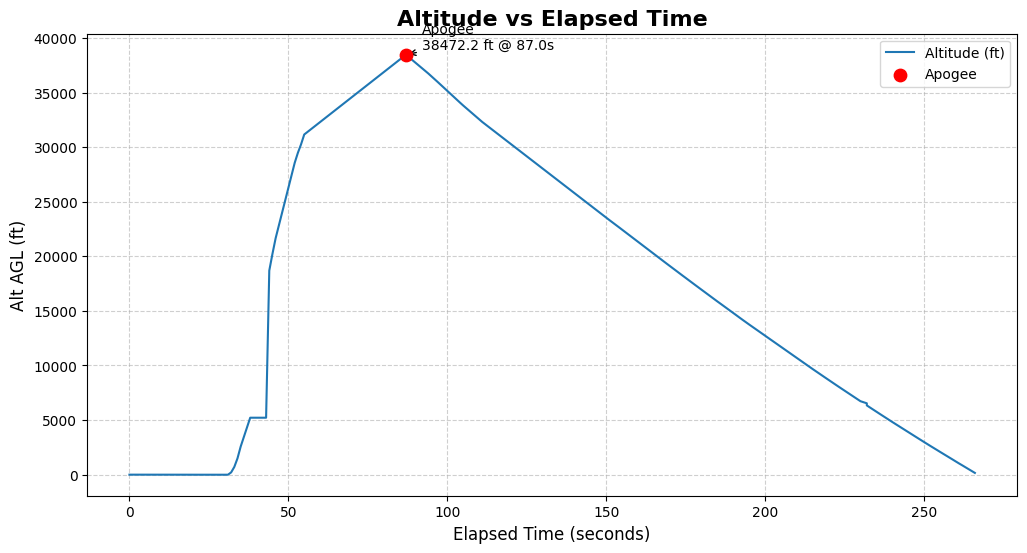

In [ ]:
# Rocket Telemetry Data Analysis

%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create plots directory for saving high-resolution images
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' folder for saving plot images")

df = pd.read_csv("Trimmed Aurora Telemetry Data.csv")

# Convert TIME column to datetime format for proper time calculations
df['TIME'] = pd.to_datetime(df['TIME'], format='%I:%M:%S %p')

# Calculate elapsed time in seconds from the first timestamp
start_time = df['TIME'].iloc[0]
df['elapsed_seconds'] = (df['TIME'] - start_time).dt.total_seconds()

# Convert altitude to numeric values (handles any string data)
df['Alt AGL (ft)'] = pd.to_numeric(df['Alt AGL (ft)'], errors='coerce')

print("Rocket Telemetry Data Summary:")
print("=" * 40)
print("First few rows with elapsed time:")
print(df[['TIME', 'elapsed_seconds', 'Alt AGL (ft)']].head())

# Find apogee (maximum altitude point)
apogee_idx = df['Alt AGL (ft)'].idxmax()   # row where altitude is max
apogee_time = df.loc[apogee_idx, 'elapsed_seconds']  # time at apogee
apogee_alt  = df.loc[apogee_idx, 'Alt AGL (ft)']

print(f"\nFlight Analysis:")
print(f"Apogee: {apogee_alt:.1f} ft at {apogee_time:.1f} seconds")

# Create altitude vs time plot
plt.figure(figsize=(12, 6)) 
plt.plot(df['elapsed_seconds'], df['Alt AGL (ft)'], 'b-', linewidth=2, label='Altitude (ft)')

plt.scatter([apogee_time], [apogee_alt], color='red', s=80, zorder=5, label='Apogee')

plt.annotate(f'Apogee\n{apogee_alt:.1f} ft @ {apogee_time:.1f}s', 
             xy=(apogee_time, apogee_alt), 
             xytext=(apogee_time + 5, apogee_alt + 500), # offset label
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=10, color='black')

plt.title('Rocket Altitude vs Elapsed Time', fontsize=16, fontweight='bold')
plt.xlabel('Elapsed Time (seconds)', fontsize=12)
plt.ylabel('Altitude AGL (ft)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save plots in multiple formats for different uses
plt.savefig('plots/altitude_vs_time.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('plots/altitude_vs_time.pdf', bbox_inches='tight', facecolor='white')
print(f"Saved altitude plot: plots/altitude_vs_time.png and .pdf")

plt.show()

GPS TRAJECTORY & LATERAL VELOCITY ANALYSIS
Found GPS columns: TRACKER Lat, TRACKER Lon
Processing 100 GPS data points...

 GPS ANALYSIS RESULTS:
Maximum lateral velocity: 3831.9 ft/s
Average lateral velocity: 93.7 ft/s
Maximum distance from launch: 18067.8 feet
Saved GPS analysis plots: plots/gps_trajectory_analysis.png and .pdf
Saved GPS analysis plots: plots/gps_trajectory_analysis.png and .pdf


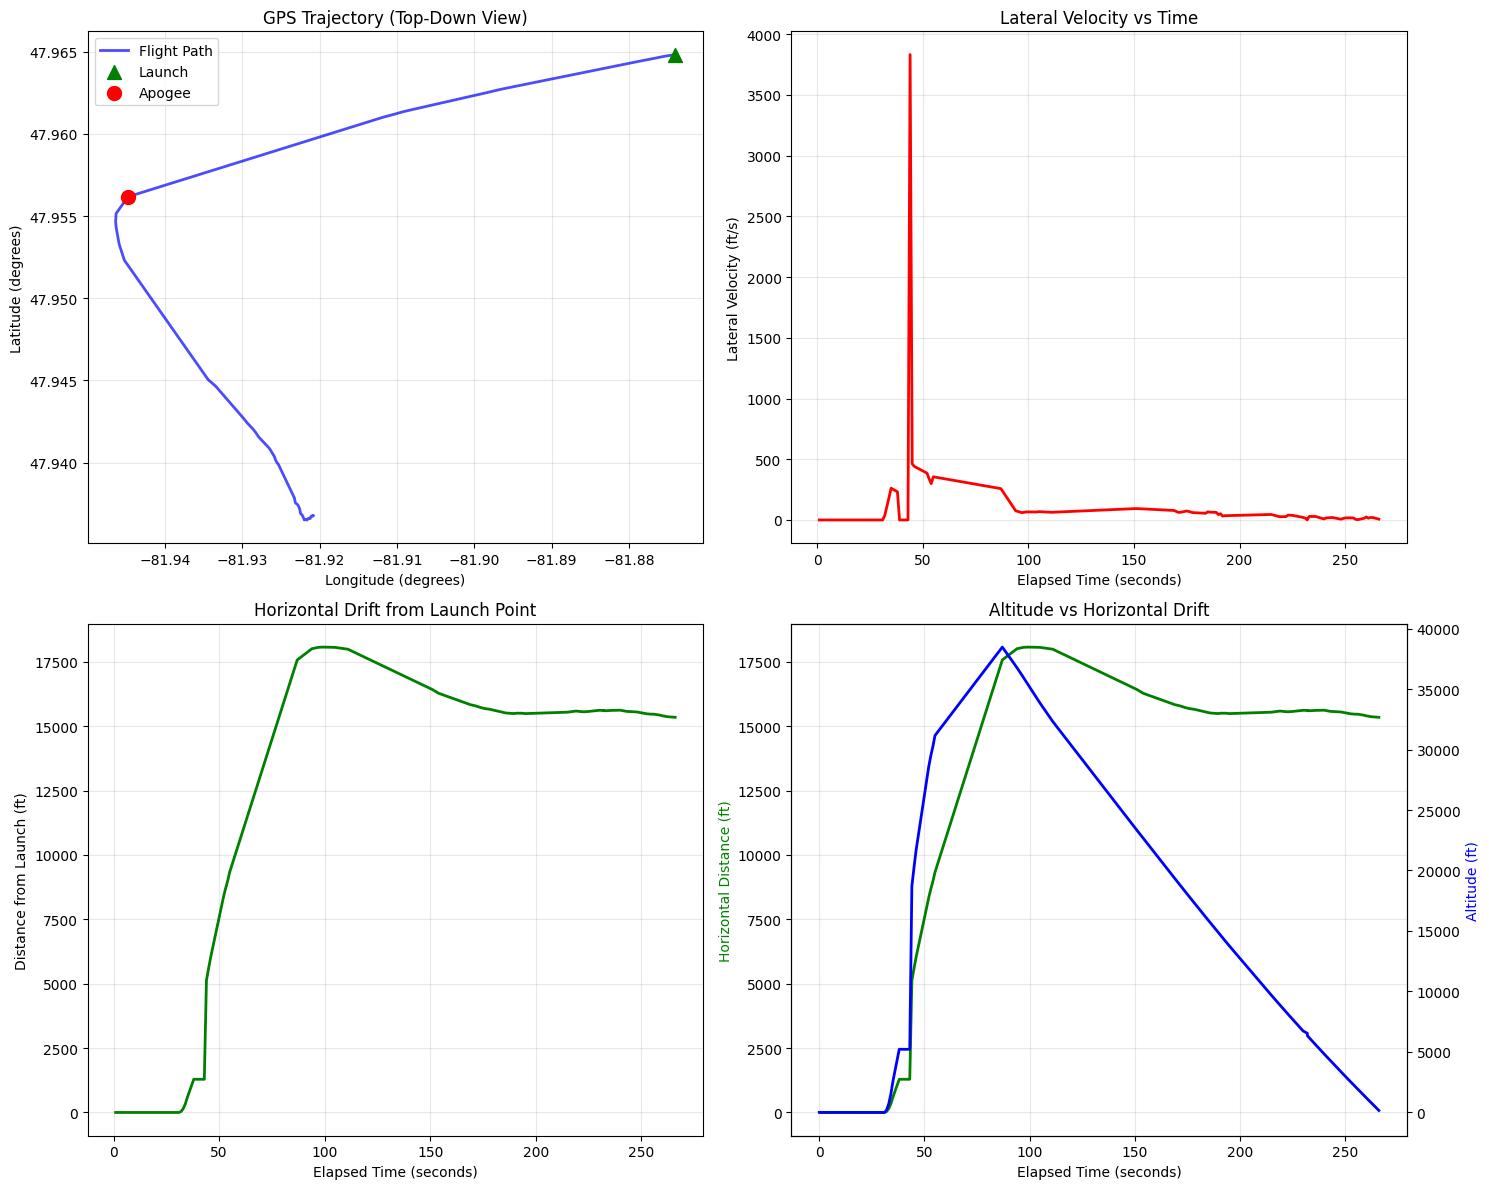

In [ ]:
# GPS Trajectory and Lateral Velocity Analysis
# Updated: September 30, 2025

latitude_col = 'TRACKER Lat'
longitude_col = 'TRACKER Lon'

print("GPS TRAJECTORY & LATERAL VELOCITY ANALYSIS")
print("=" * 55)

if latitude_col in df.columns and longitude_col in df.columns:
    print(f"Found GPS columns: {latitude_col}, {longitude_col}")
    
    # Convert GPS coordinates to numeric format
    df[latitude_col] = pd.to_numeric(df[latitude_col], errors='coerce')
    df[longitude_col] = pd.to_numeric(df[longitude_col], errors='coerce')
    
    # Remove rows with missing GPS data
    gps_data = df.dropna(subset=[latitude_col, longitude_col, 'elapsed_seconds']).copy()
    
    if len(gps_data) > 1:
        # Haversine formula for calculating distance between GPS points
        def haversine_distance(lat1, lon1, lat2, lon2):
            """
            Calculate distance between two GPS points using Haversine formula
            Returns distance in feet (using Earth's radius in feet)
            """
            from math import radians, sin, cos, sqrt, asin
            
            # Convert decimal degrees to radians
            lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
            
            # Haversine formula - accounts for Earth's curvature
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
            c = 2 * asin(sqrt(a))
            
            # Earth's radius in feet (for imperial units)
            earth_radius_ft = 20902231
            return earth_radius_ft * c

        # Calculate distances and velocities between consecutive GPS points
        distances = []
        lateral_velocities = []
        
        print(f"Processing {len(gps_data)} GPS data points...")
        
        for i in range(1, len(gps_data)):
            # Distance between consecutive GPS readings
            dist = haversine_distance(
                gps_data.iloc[i-1][latitude_col], gps_data.iloc[i-1][longitude_col],
                gps_data.iloc[i][latitude_col], gps_data.iloc[i][longitude_col]
            )
            distances.append(dist)
            
            # Time difference between GPS readings
            time_diff = gps_data.iloc[i]['elapsed_seconds'] - gps_data.iloc[i-1]['elapsed_seconds']

            # Calculate lateral velocity (horizontal speed in ft/s)
            if time_diff > 0:
                velocity = dist / time_diff  # ft/s
                lateral_velocities.append(velocity)
            else:
                lateral_velocities.append(0)
        
        # Add calculated metrics to dataframe
        gps_data = gps_data.iloc[1:].copy()  # Skip first row (no previous point)
        gps_data['lateral_distance_ft'] = distances
        gps_data['lateral_velocity_fts'] = lateral_velocities
        
        # Calculate cumulative horizontal distance from launch point
        launch_lat = df.iloc[0][latitude_col]
        launch_lon = df.iloc[0][longitude_col]

        gps_data['distance_from_launch_ft'] = [
            haversine_distance(launch_lat, launch_lon, row[latitude_col], row[longitude_col])
            for _, row in gps_data.iterrows()
        ]
        
        # Display analysis results
        print(f"\nGPS ANALYSIS RESULTS:")
        print(f"Maximum lateral velocity: {max(lateral_velocities):.1f} ft/s")
        print(f"Average lateral velocity: {np.mean(lateral_velocities):.1f} ft/s")
        print(f"Maximum distance from launch: {max(gps_data['distance_from_launch_ft']):.1f} feet")
        
        # Create comprehensive 4-panel GPS analysis plot
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # Plot 1: GPS Trajectory (Bird's Eye View)
        ax1.plot(df[longitude_col], df[latitude_col], 'b-', linewidth=2, alpha=0.7, label='Flight Path')
        ax1.scatter(df.iloc[0][longitude_col], df.iloc[0][latitude_col], 
                   color='green', s=100, marker='^', label='Launch', zorder=5)
        ax1.scatter(df.iloc[apogee_idx][longitude_col], df.iloc[apogee_idx][latitude_col], 
                   color='red', s=100, marker='o', label='Apogee', zorder=5)
        ax1.set_xlabel('Longitude (degrees)')
        ax1.set_ylabel('Latitude (degrees)')
        ax1.set_title('GPS Trajectory (Top-Down View)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Lateral Velocity Over Time
        ax2.plot(gps_data['elapsed_seconds'], gps_data['lateral_velocity_fts'], 'r-', linewidth=2)
        ax2.set_xlabel('Elapsed Time (seconds)')
        ax2.set_ylabel('Lateral Velocity (ft/s)')
        ax2.set_title('Lateral Velocity vs Time')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Horizontal Drift from Launch
        ax3.plot(gps_data['elapsed_seconds'], gps_data['distance_from_launch_ft'], 'g-', linewidth=2)
        ax3.set_xlabel('Elapsed Time (seconds)')
        ax3.set_ylabel('Distance from Launch (ft)')
        ax3.set_title('Horizontal Drift from Launch Point')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Combined Altitude and Horizontal Movement
        ax4.plot(gps_data['elapsed_seconds'], gps_data['distance_from_launch_ft'], 
                'g-', linewidth=2, label='Horizontal Distance')
        ax4_twin = ax4.twinx()
        ax4_twin.plot(df['elapsed_seconds'], df['Alt AGL (ft)'], 'b-', linewidth=2, label='Altitude')
        ax4.set_xlabel('Elapsed Time (seconds)')
        ax4.set_ylabel('Horizontal Distance (ft)', color='g')
        ax4_twin.set_ylabel('Altitude (ft)', color='b')
        ax4.set_title('Altitude vs Horizontal Drift')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save comprehensive GPS analysis plots
        plt.savefig('plots/gps_trajectory_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('plots/gps_trajectory_analysis.pdf', bbox_inches='tight', facecolor='white')
        print(f"Saved GPS analysis plots: plots/gps_trajectory_analysis.png and .pdf")
        
        plt.show()
        
    else:
        print("Not enough valid GPS data points for analysis")
        
else:
    print("GPS columns not found. Available columns:")
    print(df.columns.tolist())
    print(f"\nPlease update the column names:")
    print(f"latitude_col = 'YourActualLatColumnName'")
    print(f"longitude_col = 'YourActualLonColumnName'")

In [22]:
print("PLOT SAVING SUMMARY:")
print("=" * 50)

import os
if os.path.exists('plots'):
    saved_plots = [f for f in os.listdir('plots') if f.endswith(('.png', '.pdf', '.jpg', '.svg'))]
    if saved_plots:
        print(f"Found {len(saved_plots)} saved plot files:")
        for plot in sorted(saved_plots):
            file_size = os.path.getsize(f'plots/{plot}') / 1024
            print(f"    {plot} ({file_size:.1f} KB)")
    else:
        print("No plot files found in 'plots' folder")
else:
    print("'plots' folder not found")

PLOT SAVING SUMMARY:
Found 4 saved plot files:
    altitude_vs_time.pdf (21.2 KB)
    altitude_vs_time.png (186.0 KB)
    gps_trajectory_analysis.pdf (24.4 KB)
    gps_trajectory_analysis.png (490.8 KB)
